In [1]:
import numpy as np

np.random.seed(42)

n_students = 100

midterm = np.clip(np.random.normal(70, 15, n_students), 0, 100)
final = np.clip(np.random.normal(75, 15, n_students), 0, 100)


In [2]:
assignments = np.clip(
    np.random.normal(80, 10, 500), 0, 100
).reshape(n_students, 5)

In [3]:
departments = np.random.choice(
    ['CS', 'EE', 'PHYS', 'CHEM', 'BIO'],
    size=n_students
)


In [4]:
def introduce_nan(arr, percent=0.05):
    n = int(len(arr) * percent)
    idx = np.random.choice(len(arr), n, replace=False)
    arr[idx] = np.nan

introduce_nan(midterm)
introduce_nan(final)

for i in range(5):
    introduce_nan(assignments[:, i])

introduce_nan(departments)


In [5]:
import pandas as pd

df = pd.DataFrame({
    'StudentID': np.arange(1, n_students + 1),
    'Department': departments,
    'Midterm': midterm,
    'Final': final
})

for i in range(5):
    df[f'Assignment_{i+1}'] = assignments[:, i]


In [6]:
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])


In [7]:
numeric_cols = ['Midterm', 'Final'] + [f'Assignment_{i+1}' for i in range(5)]

df[numeric_cols] = df.groupby('Department')[numeric_cols].transform(
    lambda x: x.fillna(x.mean())
)


In [8]:
df['Assignment_Avg'] = df[[f'Assignment_{i+1}' for i in range(5)]].mean(axis=1)

df['Total_Score'] = (
    0.25 * df['Midterm'] +
    0.25 * df['Final'] +
    0.50 * df['Assignment_Avg']
)


In [9]:
def grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

df['Grade'] = df['Total_Score'].apply(grade)


In [10]:
summary = df.groupby('Department').agg(
    Avg_Total=('Total_Score', 'mean'),
    Std_Total=('Total_Score', 'std'),
    Avg_Midterm=('Midterm', 'mean'),
    Avg_Final=('Final', 'mean'),
    Student_Count=('StudentID', 'count')
)


In [11]:
import matplotlib.pyplot as plt


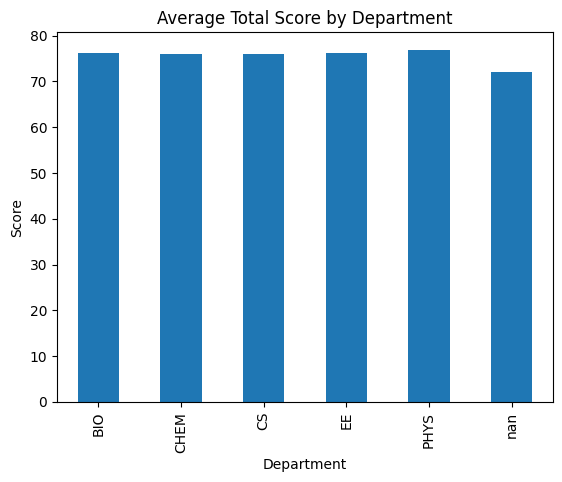

In [12]:
summary['Avg_Total'].plot(kind='bar')
plt.title('Average Total Score by Department')
plt.ylabel('Score')
plt.show()


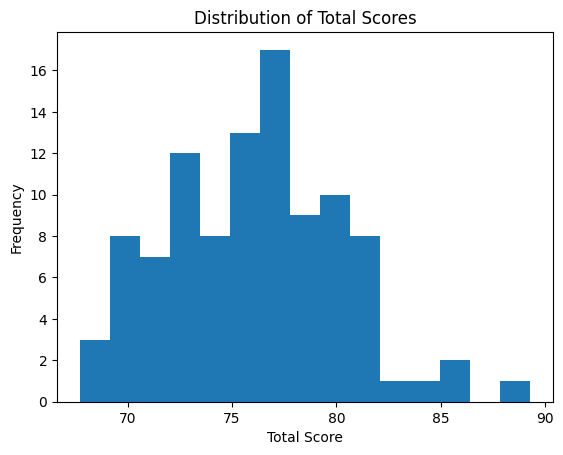

In [13]:
plt.hist(df['Total_Score'], bins=15)
plt.title('Distribution of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.show()


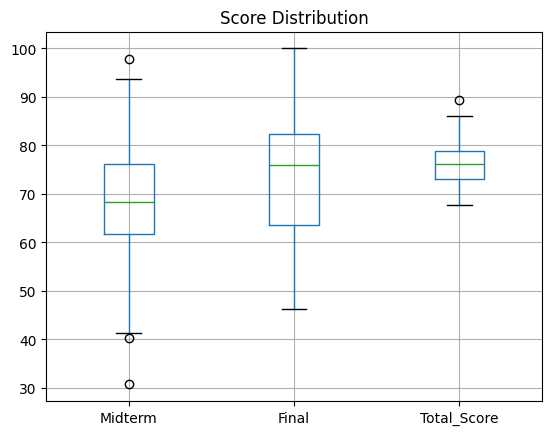

In [14]:
df[['Midterm', 'Final', 'Total_Score']].boxplot()
plt.title('Score Distribution')
plt.show()


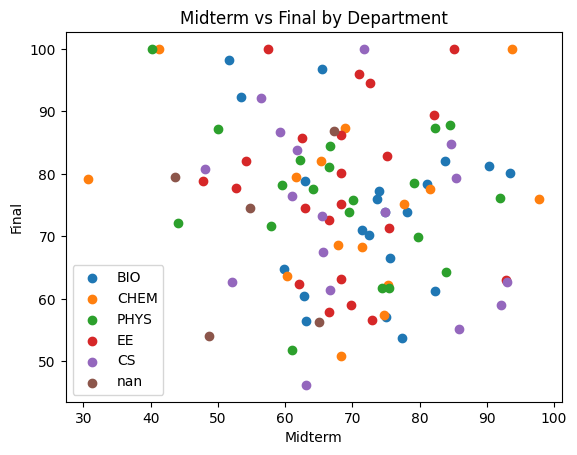

In [15]:
for dept in df['Department'].unique():
    subset = df[df['Department'] == dept]
    plt.scatter(subset['Midterm'], subset['Final'], label=dept)

plt.xlabel('Midterm')
plt.ylabel('Final')
plt.legend()
plt.title('Midterm vs Final by Department')
plt.show()


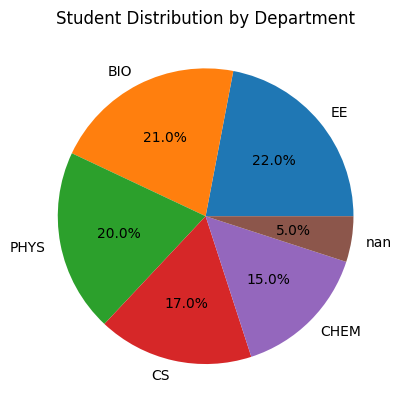

In [16]:
df['Department'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Student Distribution by Department')
plt.ylabel('')
plt.show()


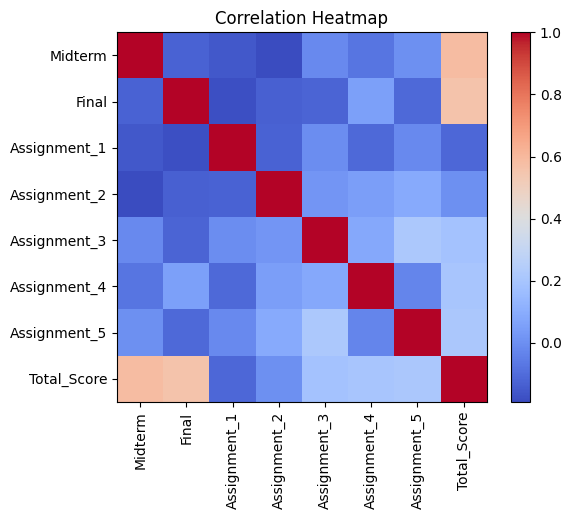

In [17]:
corr = df[numeric_cols + ['Total_Score']].corr()

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()


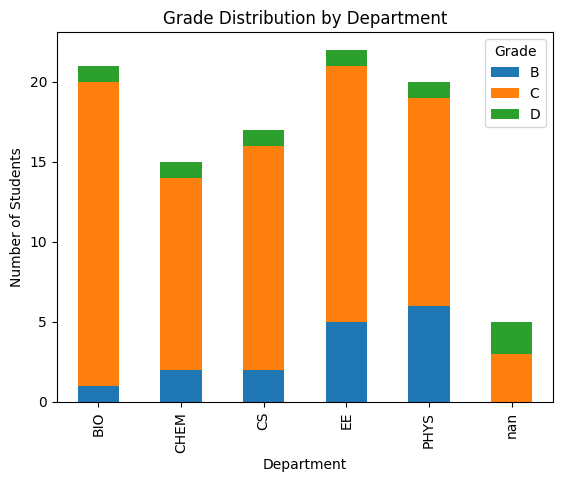

In [18]:
grade_dist = pd.crosstab(df['Department'], df['Grade'])
grade_dist.plot(kind='bar', stacked=True)
plt.title('Grade Distribution by Department')
plt.ylabel('Number of Students')
plt.show()
